
--- Ecuación de Regresión Lineal (Datos Completos) ---
p = 5.02 * a + 49.23

--- Ecuación de Regresión Lineal (Subgrupo 1) ---
p = 3.82 * a + 102.21

--- Ecuación de Regresión Lineal (Subgrupo 2) ---
p = 5.69 * a + 13.61


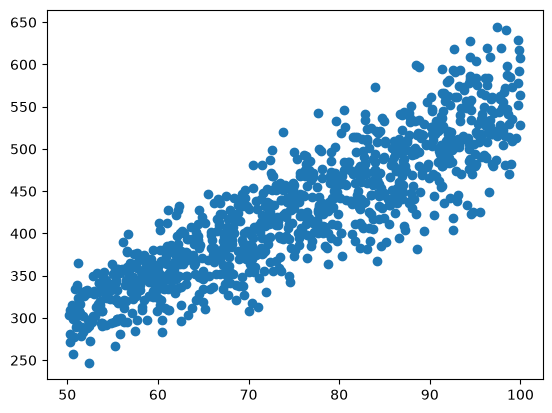

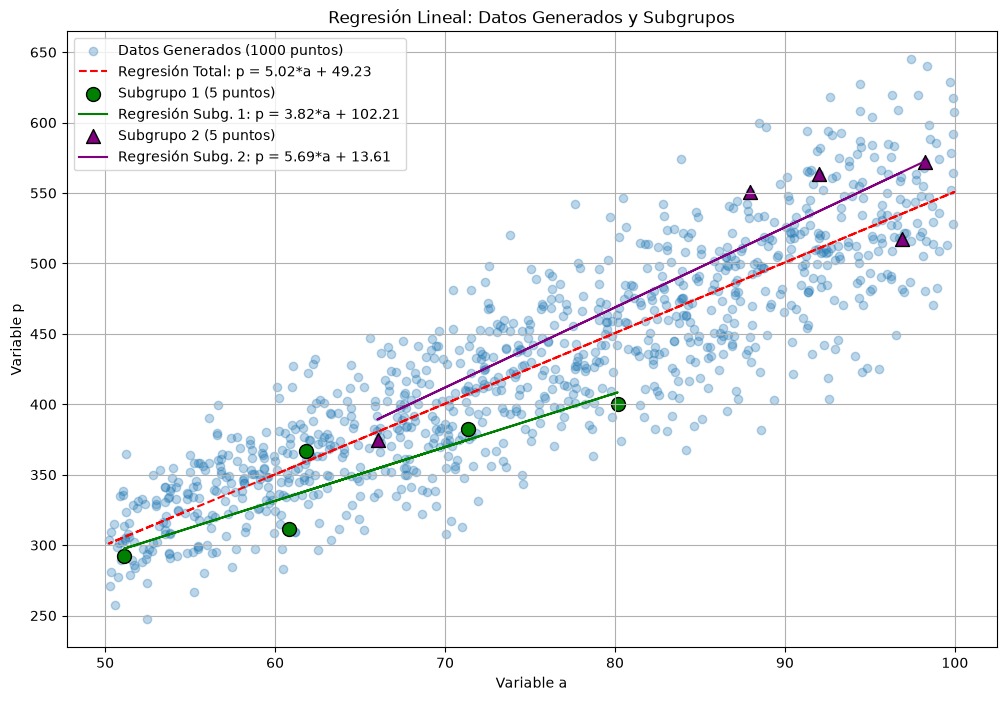

In [ ]:
import numpy as np
import json
from scipy.stats import linregress
import matplotlib.pyplot as plt
import pandas as pd


data_ap=json.load(open('data_area_precio.json'))

# Convertir a DataFrame para facilitar el manejo
df_ap = pd.DataFrame(data_ap)
num_data_points=len(df_ap)
# 2. Regresión lineal para el conjunto completo de datos
slope_full, intercept_full, r_value_full, p_value_full, std_err_full = linregress(df_ap['a'], df_ap['p'])

print("\n--- Ecuación de Regresión Lineal (Datos Completos) ---")
print(f"p = {slope_full:.2f} * a + {intercept_full:.2f}")

# 3. Generar 2 subgrupos de 5 datos y hacer regresión lineal

# Subgrupo 1
subgroup1_indices = np.random.choice(num_data_points, 5, replace=False)
df_subgroup1 = df_ap.iloc[subgroup1_indices]

slope_s1, intercept_s1, r_value_s1, p_value_s1, std_err_s1 = linregress(df_subgroup1['a'], df_subgroup1['p'])

print("\n--- Ecuación de Regresión Lineal (Subgrupo 1) ---")
print(f"p = {slope_s1:.2f} * a + {intercept_s1:.2f}")

# Subgrupo 2
# Asegurarse de que el subgrupo 2 no tenga los mismos datos que el subgrupo 1
remaining_indices = list(set(range(num_data_points)) - set(subgroup1_indices))
subgroup2_indices = np.random.choice(remaining_indices, 5, replace=False)
df_subgroup2 = df_ap.iloc[subgroup2_indices]

slope_s2, intercept_s2, r_value_s2, p_value_s2, std_err_s2 = linregress(df_subgroup2['a'], df_subgroup2['p'])

print("\n--- Ecuación de Regresión Lineal (Subgrupo 2) ---")
print(f"p = {slope_s2:.2f} * a + {intercept_s2:.2f}")

# Visualización
plt.figure(figsize=(12, 8))
plt.scatter(df_ap['a'], df_ap['p'], alpha=0.3, label='Datos Generados (1000 puntos)')

# Línea de regresión para todos los datos
plt.plot(df_ap['a'], slope_full * df_ap['a'] + intercept_full, color='red', linestyle='--', label=f'Regresión Total: p = {slope_full:.2f}*a + {intercept_full:.2f}')

# Puntos y líneas de regresión para subgrupos
plt.scatter(df_subgroup1['a'], df_subgroup1['p'], color='green', marker='o', s=100, edgecolors='black', label='Subgrupo 1 (5 puntos)')
plt.plot(df_subgroup1['a'], slope_s1 * df_subgroup1['a'] + intercept_s1, color='green', linestyle='-', label=f'Regresión Subg. 1: p = {slope_s1:.2f}*a + {intercept_s1:.2f}')

plt.scatter(df_subgroup2['a'], df_subgroup2['p'], color='purple', marker='^', s=100, edgecolors='black', label='Subgrupo 2 (5 puntos)')
plt.plot(df_subgroup2['a'], slope_s2 * df_subgroup2['a'] + intercept_s2, color='purple', linestyle='-', label=f'Regresión Subg. 2: p = {slope_s2:.2f}*a + {intercept_s2:.2f}')

plt.title('Regresión Lineal: Datos Generados y Subgrupos')
plt.xlabel('Variable a')
plt.ylabel('Variable p')
plt.legend()
plt.grid(True)
plt.show()
